# Assignment 5: Domain Adaptation with Language Model

## Data Loading
I used the following datasets for this assignment.

1. Myanmar Written Corpus : [Myanmar Written Corpus (freococo, 2024)](https://huggingface.co/datasets/freococo/myanmar-written-corpus)
2. myPoetry2023 : [myPoetry](https://github.com/ye-kyaw-thu/myPoetry)
3. myNews : [myNews](https://github.com/ye-kyaw-thu/myNews)

I used the following tools to clean, break syllable and words.

1. [Syllable Normalization Tool for Myanmar Language](https://github.com/ye-kyaw-thu/syl-Normalizer/tree/main/ver_0.6)
2. [oppaWord: Hybrid DAG+Bi-MM+LM Myanmar Word Segmenter](https://github.com/ye-kyaw-thu/oppaWord)

#### Helpers

In [1]:
import subprocess
import yaml
import re
import sys

def run_cmd(cmd_list):
    """
    Helper function to run shell commands safely.
    Streams stdout/stderr to system null or keeps buffers minimal 
    instead of storing massive output strings in RAM.
    """
    # Using text=True but letting it stream or discarding output if successful 
    # protects memory if the underlying scripts are chatty.
    result = subprocess.run(cmd_list, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if result.returncode != 0:
        print(f"Error running command: {' '.join(cmd_list)}")
        print(result.stderr)
    else:
        print(f"Success: {' '.join(cmd_list[:3])}...")

def filter_myanmar_only(input_file, output_file):
    """Filters file to keep only Myanmar script, spaces, and punctuation."""
    myanmar_regex = re.compile(r'^[\u1000-\u109f\s၊။]+$')
    
    # Using buffered writing with a custom buffer size (e.g., 64KB) for stable I/O
    with open(input_file, "r", encoding="utf-8", buffering=65536) as fin, \
         open(output_file, "w", encoding="utf-8", buffering=65536) as fout:
        for line in fin:
            if myanmar_regex.match(line):
                fout.write(line)

def limit_tokens(input_file, output_file, max_tokens):
    """Cleanly truncate text files to a fixed token count with minimal allocations."""
    print(f"Truncating {input_file} to {max_tokens} tokens -> {output_file}")
    token_count = 0
    
    # We use a regex generator to find tokens without building large lists via .split()
    word_finder = re.compile(r'\S+') 
    
    with open(input_file, "r", encoding="utf-8", buffering=65536) as fin, \
         open(output_file, "w", encoding="utf-8", buffering=65536) as fout:
        for line in fin:
            out_words = []
            for match in word_finder.finditer(line):
                token_count += 1
                if token_count <= max_tokens:
                    out_words.append(match.group())
                else:
                    if out_words:
                        fout.write(" ".join(out_words) + "\n")
                    return # Hard stop as soon as limit is hit
            if out_words:
                fout.write(" ".join(out_words) + "\n")

def process_syllables(input_file, break_file, norm_file, dict_norm, norm_freq, norm_fuzzy, log_file=None):
    """Runs external processes using streams to ensure low memory footprint."""
    # 1. Syllable Break (Perl)
    # Open files directly as file-object streams to pass straight to the OS kernel
    with open(input_file, "r", encoding="utf-8") as fin, open(break_file, "w", encoding="utf-8") as fout:
        subprocess.run(
            ["perl", "../assignment/sylbreak/perl/sylbreak.pl", "-s", " "], 
            stdin=fin, 
            stdout=fout
        )
    
    # 2. Syllable Normalizer (Python Script)
    cmd = [
        "python", "../assignment/syl-Normalizer/ver_0.6/syl_normalizer.py",
        "--dictionary", dict_norm,
        "--frequency", str(norm_freq),
        "--input", break_file,
        "--output", norm_file,
        "--fuzzy-distance", str(norm_fuzzy)
    ]
    if log_file:
        cmd.extend(["--log", "../assignment/tmp_dir/corrections.log", "--error-output", "../assignment/tmp_dir/errors.txt"])
        
    run_cmd(cmd)

def run_clean_pipeline(cfg_file):
    with open(cfg_file, "r") as f:
        cfg = yaml.safe_load(f)
    
    print("--- Starting Text Cleaning Pipeline ---")
    
    # Step 1: Python clean text script
    run_cmd(["python3", "text_clean/clean_text.py", "-i", cfg['inputs']['raw'], "-o", cfg['outputs']['cleaned_raw']])
    
    # Step 2: Native Regex filter
    filter_myanmar_only(cfg['outputs']['cleaned_raw'], cfg['outputs']['myanmar_only'])
    
    # Step 3: Word Segmentation
    run_cmd([
        "python", "oppaWord/oppa_word.py", 
        "-i", cfg['outputs']['myanmar_only'], 
        "-o", cfg['outputs']['word_segmented'], 
        "-d", cfg['inputs']['dict_oppa'], 
        "--space-remove-mode", "my_not_num"
    ])
    
    # Step 4: Dynamic Token Truncation for Words
    if cfg.get('params', {}).get('token_limit') and cfg.get('outputs', {}).get('word_10k'):
        limit_tokens(cfg['outputs']['word_segmented'], cfg['outputs']['word_10k'], cfg['params']['token_limit'])
    else:
        print("Skipping Word Token Truncation (No configuration found)")
    
    # Step 5: Process Syllables
    process_syllables(
        input_file=cfg['outputs']['myanmar_only'], 
        break_file=cfg['outputs']['syl_break'], 
        norm_file=cfg['outputs']['syl_norm'], 
        dict_norm=cfg['inputs']['dict_norm'],
        norm_freq=cfg['params']['norm_frequency'],
        norm_fuzzy=cfg['params']['norm_fuzzy_distance'],
        log_file=True
    )
    
    # Step 6: Dynamic Token Truncation for Syllables
    if cfg.get('params', {}).get('token_limit') and cfg.get('outputs', {}).get('syl_10k'):
        limit_tokens(cfg['outputs']['syl_norm'], cfg['outputs']['syl_10k'], cfg['params']['token_limit'])
    else:
        print("Skipping Syllable Token Truncation (No configuration found)")
    
    print("--- Pipeline Processing Complete! ---")

### Myanmar Written Corpus

#### Training Dataset

In [2]:
%%writefile configuration/train_config.yaml
# File Paths
inputs:
  raw: "dataset/train.txt"
  raw_my: "dataset/train_clean_my.txt"
  dict_oppa: "oppaWord/data/myg2p_mypos_name.dict"
  dict_norm: "../assignment/syl-Normalizer/ver_0.6/final_syl_dictionary_13Feb2024.sorted.txt"

outputs:
  cleaned_raw: "dataset/train_clean.txt"
  myanmar_only: "dataset/train_clean_my.txt"
  word_segmented: "dataset/train_clean_my.word"
  # word_10k: "dataset/train_clean_my_10k.word"
  
  syl_break: "dataset/train_clean_my_syl.txt"
  syl_norm: "dataset/train_clean_my_syl.syl"
  # syl_10k: "dataset/train_clean_my_syl_10k.syl"
  
# Configuration parameters
params:
  # token_limit: 10000
  norm_frequency: 2
  norm_fuzzy_distance: 0

Overwriting configuration/train_config.yaml


In [3]:
run_clean_pipeline('configuration/train_config.yaml')

--- Starting Text Cleaning Pipeline ---
Success: python3 text_clean/clean_text.py -i...
Success: python oppaWord/oppa_word.py -i...
Skipping Word Token Truncation (No configuration found)


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").


Success: python ../assignment/syl-Normalizer/ver_0.6/syl_normalizer.py --dictionary...
Skipping Syllable Token Truncation (No configuration found)
--- Pipeline Processing Complete! ---


#### Baseline Test Dataset

In [4]:
%%writefile configuration/test_config.yaml
# File Paths
inputs:
  raw: "dataset/test.txt"
  raw_my: "dataset/test_clean_my.txt"
  dict_oppa: "oppaWord/data/myg2p_mypos_name.dict"
  dict_norm: "../assignment/syl-Normalizer/ver_0.6/final_syl_dictionary_13Feb2024.sorted.txt"

outputs:
  cleaned_raw: "dataset/test_clean.txt"
  myanmar_only: "dataset/test_clean_my.txt"
  word_segmented: "dataset/test_clean_my.word"
  word_10k: "dataset/test_clean_my_10k.word"
  
  syl_break: "dataset/test_clean_my_syl.txt"
  syl_norm: "dataset/test_clean_my_syl.syl"
  syl_10k: "dataset/test_clean_my_syl_10k.syl"
  
# Configuration parameters
params:
  token_limit: 10000
  norm_frequency: 2
  norm_fuzzy_distance: 0

Writing configuration/test_config.yaml


In [5]:
run_clean_pipeline('configuration/test_config.yaml')

--- Starting Text Cleaning Pipeline ---
Success: python3 text_clean/clean_text.py -i...
Success: python oppaWord/oppa_word.py -i...
Truncating dataset/test_clean_my.word to 10000 tokens -> dataset/test_clean_my_10k.word


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").


Success: python ../assignment/syl-Normalizer/ver_0.6/syl_normalizer.py --dictionary...
Truncating dataset/test_clean_my_syl.syl to 10000 tokens -> dataset/test_clean_my_syl_10k.syl
--- Pipeline Processing Complete! ---


#### myPoetry Dataset

In [6]:
%%writefile configuration/myPoetry_config.yaml
# File Paths
inputs:
  raw: "dataset/myPoetry/corpus/version1.0/mypoetry-corpus-notitle-ver1.0.txt"
  raw_my: "dataset/myPoetry_clean_my.txt"
  dict_oppa: "oppaWord/data/myg2p_mypos_name.dict"
  dict_norm: "../assignment/syl-Normalizer/ver_0.6/final_syl_dictionary_13Feb2024.sorted.txt"

outputs:
  cleaned_raw: "dataset/myPoetry_clean.txt"
  myanmar_only: "dataset/myPoetry_clean_my.txt"
  word_segmented: "dataset/myPoetry_clean_my.word"
  word_10k: "dataset/myPoetry_clean_my_10k.word"
  
  syl_break: "dataset/myPoetry_clean_my_syl.txt"
  syl_norm: "dataset/myPoetry_clean_my_syl.syl"
  syl_10k: "dataset/myPoetry_clean_my_syl_10k.syl"
  
# Configuration parameters
params:
  token_limit: 10000
  norm_frequency: 2
  norm_fuzzy_distance: 0

Writing configuration/myPoetry_config.yaml


In [7]:
run_clean_pipeline('configuration/myPoetry_config.yaml')

--- Starting Text Cleaning Pipeline ---
Success: python3 text_clean/clean_text.py -i...
Success: python oppaWord/oppa_word.py -i...
Truncating dataset/myPoetry_clean_my.word to 10000 tokens -> dataset/myPoetry_clean_my_10k.word


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").


Success: python ../assignment/syl-Normalizer/ver_0.6/syl_normalizer.py --dictionary...
Truncating dataset/myPoetry_clean_my_syl.syl to 10000 tokens -> dataset/myPoetry_clean_my_syl_10k.syl
--- Pipeline Processing Complete! ---


#### myNews Dataset

In [8]:
%%writefile configuration/myNews_config.yaml
# File Paths
inputs:
  raw: "dataset/myNews.txt"
  raw_my: "dataset/myNews_clean_my.txt"
  dict_oppa: "oppaWord/data/myg2p_mypos_name.dict"
  dict_norm: "../assignment/syl-Normalizer/ver_0.6/final_syl_dictionary_13Feb2024.sorted.txt"

outputs:
  cleaned_raw: "dataset/myNews_clean.txt"
  myanmar_only: "dataset/myNews_clean_my.txt"
  word_segmented: "dataset/myNews_clean_my.word"
  word_10k: "dataset/myNews_clean_my_10k.word"
  
  syl_break: "dataset/myNews_clean_my_syl.txt"
  syl_norm: "dataset/myNews_clean_my_syl.syl"
  syl_10k: "dataset/myNews_clean_my_syl_10k.syl"
  
# Configuration parameters
params:
  token_limit: 10000
  norm_frequency: 2
  norm_fuzzy_distance: 0

Writing configuration/myNews_config.yaml


In [9]:
run_clean_pipeline('configuration/myNews_config.yaml')

--- Starting Text Cleaning Pipeline ---
Success: python3 text_clean/clean_text.py -i...
Success: python oppaWord/oppa_word.py -i...
Truncating dataset/myNews_clean_my.word to 10000 tokens -> dataset/myNews_clean_my_10k.word


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").


Success: python ../assignment/syl-Normalizer/ver_0.6/syl_normalizer.py --dictionary...
Truncating dataset/myNews_clean_my_syl.syl to 10000 tokens -> dataset/myNews_clean_my_syl_10k.syl
--- Pipeline Processing Complete! ---


## KenLM
`Myanmar Written Corpus` training dataset are going to train with KenLM 3 gram and 5 gram models. After that these LM will be evaluate on `Myanmar Written Corpus` test dataset, `myPoetry` dataset and `myNews` dataset. PPL was used as evaluation matrix.

#### Helpers

In [10]:
import os
import subprocess
import yaml
import math
import matplotlib.pyplot as plt
from pathlib import Path

# --- Helper Math Functions ---
def log10_to_nats(log10_val):
    return log10_val * math.log(10)

def compute_ppl_and_entropy(negative_sum_nats, n_tokens):
    if n_tokens == 0:
        return float('inf'), 0.0
    entropy = negative_sum_nats / n_tokens
    ppl = math.exp(entropy)
    return ppl, entropy

# --- Core KenLM Parser and Pipeline Execution ---
def run_kenlm_pipeline(cfg_file):
    # 1. Load the Configuration
    with open(cfg_file, "r") as f:
        cfg = yaml.safe_load(f)
        
    train_f = cfg['paths']['train_file']
    out_dir = cfg['paths']['output_dir']
    tmp_dir = cfg['paths']['tmp_dir']
    
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(tmp_dir, exist_ok=True)
    
    # Delayed import of kenlm so script loads smoothly
    import kenlm

    # Dictionary to hold final evaluation results for plotting
    # Format: {model_order: {test_name: ppl}}
    plot_data = {}

    print("=== Starting KenLM Loop Execution ===")
    
    # 2. Loop Through Specified Models (e.g., 3-gram, 5-gram)
    for order in cfg['models']:
        print(f"\n--- Training {order}-Gram Model ---")
        arpa_file = os.path.join(out_dir, f"train_clean_my_{order}gram.arpa")
        err_file = f"{arpa_file}.err"
        
        # Build command array safely
        # Equivalent to: !cat {train_f} | lmplz -o {order} -S 8G --discount_fallback > {arpa_file}
        lmplz_path = "kenlm/build/bin/lmplz"
        
        # We stream the training file into the stdin of lmplz via subprocess
        with open(train_f, "r", encoding="utf-8") as fin, \
             open(arpa_file, "w", encoding="utf-8") as fout, \
             open(err_file, "w", encoding="utf-8") as ferr:
            
            cmd = [lmplz_path, "-o", str(order), "-S", "8G", "-T", tmp_dir, "--discount_fallback"]
            subprocess.run(cmd, stdin=fin, stdout=fout, stderr=ferr)
            
        # 3. Validation Check
        if Path(arpa_file).stat().st_size == 0:
            print(f"ERROR: {order}-gram ARPA file is empty! Log details:")
            print(Path(err_file).read_text())
            continue
            
        # 4. Load Compiled Model
        model_kenlm = kenlm.LanguageModel(arpa_file)
        print(f"Successfully loaded {model_kenlm.order}-gram model.")
        plot_data[order] = {}

        # 5. Inner Evaluation Loop: Run every test file listed in YAML config
        for test_name, test_path in cfg['test_files'].items():
            if not os.path.exists(test_path):
                print(f"   Skipping [{test_name}]: File {test_path} not found.")
                continue
                
            sum_log10, n_tokens = 0.0, 0
            for line in Path(test_path).read_text(encoding="utf-8").splitlines():
                if not line.strip(): 
                    continue
                for prob, length, oov in model_kenlm.full_scores(line):
                    sum_log10 += prob
                    n_tokens += 1
                    
            sum_nats = log10_to_nats(sum_log10)
            ppl_kenlm, ent_kenlm = compute_ppl_and_entropy(-sum_nats, n_tokens)
            
            print(f"   Evaluation -> [{test_name}] -> PPL: {ppl_kenlm:.2f}, Entropy: {ent_kenlm:.2f} nats")
            
            # Save PPL for visual plotting
            plot_data[order][test_name] = ppl_kenlm

    # 6. Final Multi-Bar Plot Generation
    plot_results(plot_data)

def plot_results(plot_data):
    """Generates a bar chart comparing Perplexity values across configurations."""
    if not plot_data:
        print("No plot data collected.")
        return

    orders = list(plot_data.keys())
    test_names = list(next(iter(plot_data.values())).keys())

    plt.figure(figsize=(10, 6))
    
    # Construct distinct offsets for groupings if plotting multiple targets
    x_indexes = range(len(test_names))
    width = 0.25
    
    for i, order in enumerate(orders):
        ppl_values = [plot_data[order].get(name, 0) for name in test_names]
        # Shift bar alignments to fit side-by-side
        adjusted_x = [x + (i * width) for x in x_indexes]
        plt.bar(adjusted_x, ppl_values, width=width, label=f"{order}-gram")

    plt.xlabel('Test Datasets', fontsize=12, fontweight='bold')
    plt.ylabel('Perplexity (PPL) - Lower is Better', fontsize=12, fontweight='bold')
    plt.title('KenLM N-Gram Performance Comparison', fontsize=14, fontweight='bold')
    
    # Adjust ticks to fall visually in between the clustered bars
    plt.xticks([x + (width * (len(orders) - 1) / 2) for x in x_indexes], test_names)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

#### Word Level KenLM Models

In [11]:
%%writefile configuration/KenLM_word_config.yaml
# Paths
paths:
  train_file: "dataset/train_clean_my.word"
  output_dir: "dataset/kenlm"
  tmp_dir: "tmp_dir"

# N-gram configurations to loop through
models:
  - 3
  - 5

# Test evaluation datasets to loop through
test_files:
  baseline_10k: "dataset/test_clean_my_10k.word"
  myPoetry_10k: "dataset/myPoetry_clean_my_10k.word"
  myNews_10k: "dataset/myNews_clean_my_10k.word"

Writing configuration/KenLM_word_config.yaml


=== Starting KenLM Loop Execution ===

--- Training 3-Gram Model ---


Loading the LM will be faster if you build a binary file.
Reading /media/kyalkalay/Data/AI-Class/assignment-5/assignment/dataset/kenlm/train_clean_my_3gram.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


Successfully loaded 3-gram model.
   Evaluation -> [baseline_10k] -> PPL: 26.34, Entropy: 3.27 nats
   Evaluation -> [myPoetry_10k] -> PPL: 1588.04, Entropy: 7.37 nats
   Evaluation -> [myNews_10k] -> PPL: 57.46, Entropy: 4.05 nats

--- Training 5-Gram Model ---


Loading the LM will be faster if you build a binary file.
Reading /media/kyalkalay/Data/AI-Class/assignment-5/assignment/dataset/kenlm/train_clean_my_5gram.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


Successfully loaded 5-gram model.
   Evaluation -> [baseline_10k] -> PPL: 15.06, Entropy: 2.71 nats
   Evaluation -> [myPoetry_10k] -> PPL: 1239.27, Entropy: 7.12 nats
   Evaluation -> [myNews_10k] -> PPL: 46.02, Entropy: 3.83 nats


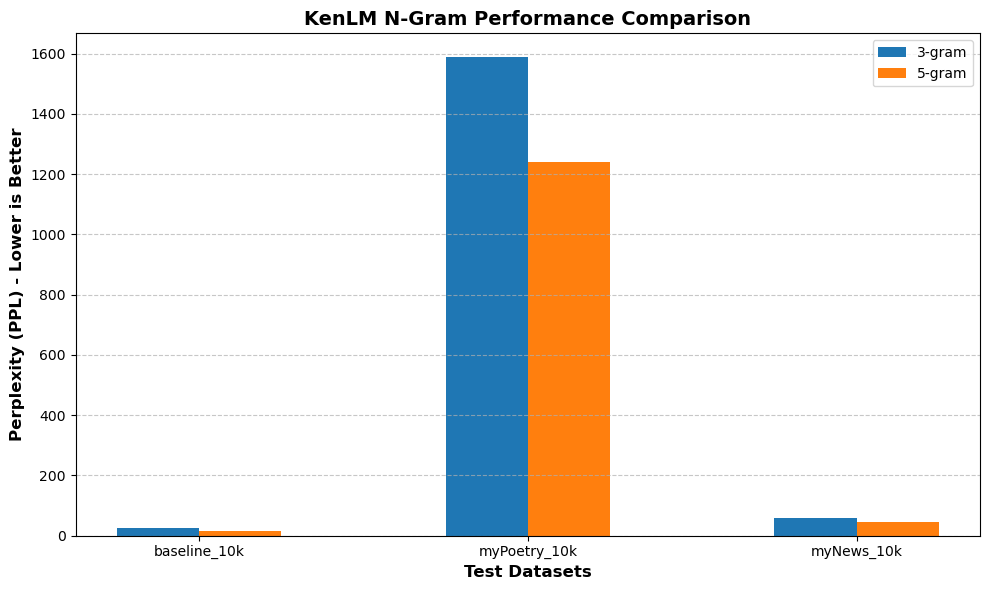

In [12]:
run_kenlm_pipeline("configuration/KenLM_word_config.yaml")

#### Syllable Level KenLM Models

In [13]:
%%writefile configuration/KenLM_syl_config.yaml
# Paths
paths:
  train_file: "dataset/train_clean_my_syl.syl"
  output_dir: "dataset/kenlm"
  tmp_dir: "tmp_dir"

# N-gram configurations to loop through
models:
  - 3
  - 5

# Test evaluation datasets to loop through
test_files:
  baseline_10k: "dataset/test_clean_my_syl_10k.syl"
  myPoetry_10k: "dataset/myPoetry_clean_my_syl_10k.syl"
  myNews_10k: "dataset/myNews_clean_my_syl_10k.syl"

Writing configuration/KenLM_syl_config.yaml


=== Starting KenLM Loop Execution ===

--- Training 3-Gram Model ---


Loading the LM will be faster if you build a binary file.
Reading /media/kyalkalay/Data/AI-Class/assignment-5/assignment/dataset/kenlm/train_clean_my_3gram.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


Successfully loaded 3-gram model.
   Evaluation -> [baseline_10k] -> PPL: 23.14, Entropy: 3.14 nats
   Evaluation -> [myPoetry_10k] -> PPL: 1794.03, Entropy: 7.49 nats
   Evaluation -> [myNews_10k] -> PPL: 34.37, Entropy: 3.54 nats

--- Training 5-Gram Model ---
Successfully loaded 5-gram model.
   Evaluation -> [baseline_10k] -> PPL: 13.21, Entropy: 2.58 nats
   Evaluation -> [myPoetry_10k] -> PPL: 1374.18, Entropy: 7.23 nats
   Evaluation -> [myNews_10k] -> PPL: 25.42, Entropy: 3.24 nats


Loading the LM will be faster if you build a binary file.
Reading /media/kyalkalay/Data/AI-Class/assignment-5/assignment/dataset/kenlm/train_clean_my_5gram.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


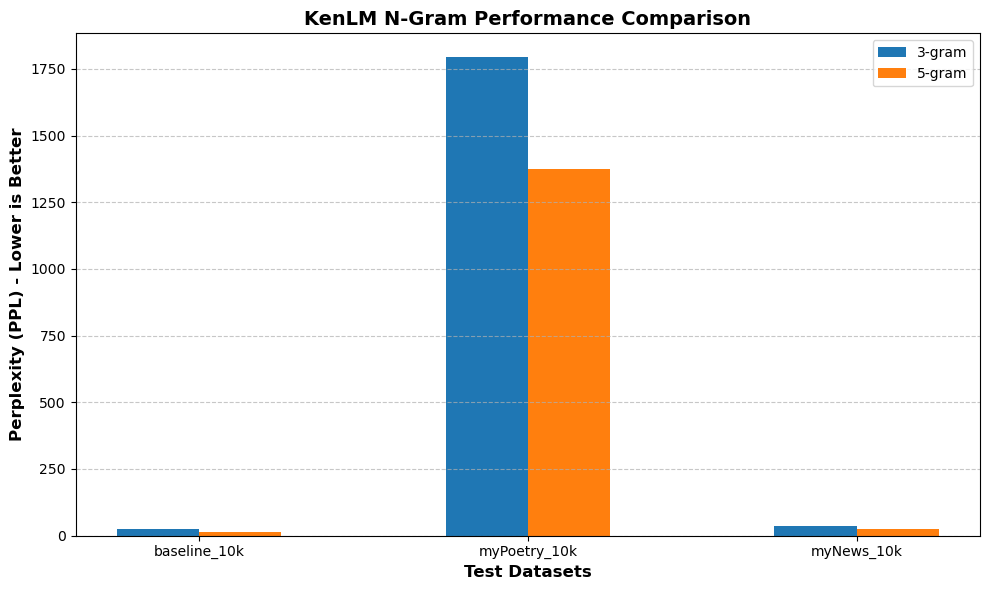

In [14]:
run_kenlm_pipeline("configuration/KenLM_syl_config.yaml")

### SRILM
Same datasets are tried to train and evaluate with SRILM.

#### Helpers

In [15]:
import os
import subprocess
import yaml
import re
import matplotlib.pyplot as plt

def parse_srilm_ppl(srilm_output_text):
    """Parses SRILM output string to extract the raw perplexity (ppl) value."""
    match = re.search(r'ppl=\s+([\d\.]+)', srilm_output_text)
    if match:
        return float(match.group(1))
    return float('inf')

def run_srilm_flexible_pipeline(cfg_file):
    # 1. Load configuration
    with open(cfg_file, "r") as f:
        cfg = yaml.safe_load(f)
        
    base_dir = cfg['workspace']
    srilm_bin = cfg['srilm_bin']
    
    train_path = os.path.join(base_dir, cfg['files']['train_file'])
    out_dir = os.path.join(base_dir, cfg['files']['output_dir'])
    os.makedirs(out_dir, exist_ok=True)
    
    # Store collected perplexity mappings for visualization
    # Format: {"3gram_kn": {"test_10k": 12.3}, "3gram_wb": {...}}
    plot_data = {}
    
    print("=== Starting Flexible SRILM Loop Execution ===")
    
    # 2. Loop Through N-Gram Orders
    for order in cfg['models']:
        # 3. Loop Through Discount Methods
        for disc in cfg['discounts']:
            disc_flag = disc['flag']
            disc_name = disc['name']
            
            # Construct a unique model identifier name
            model_id = f"{order}gram_{disc_name}"
            print(f"\n--- Training SRILM Model: {model_id.upper()} ({disc_flag}) ---")
            
            arpa_filename = f"train_clean_my_srilm_ngram_{order}_{disc_name}.arpa"
            arpa_path = os.path.join(out_dir, arpa_filename)
            
            # Dynamically build the command based on the flag provided in YAML
            count_cmd = [
                os.path.join(srilm_bin, "ngram-count"),
                "-order", str(order),
                disc_flag,  # Implements -kndiscount or -wbdiscount dynamically
                "-text", train_path,
                "-lm", arpa_path
            ]
            
            count_res = subprocess.run(count_cmd, capture_output=True, text=True)
            if count_res.returncode != 0:
                print(f"CRITICAL ERROR building model variant {model_id}:")
                print(count_res.stderr)
                continue
                
            print(f"Successfully generated ARPA: {arpa_filename}")
            plot_data[model_id] = {}
            
            # 4. Inner Evaluation Loop: Run every test dataset through the current model setup
            for test_name, relative_test_path in cfg['test_files'].items():
                full_test_path = os.path.join(base_dir, relative_test_path)
                
                if not os.path.exists(full_test_path):
                    print(f"   Skipping [{test_name}]: Target file path not found.")
                    continue
                    
                eval_cmd = [
                    os.path.join(srilm_bin, "ngram"),
                    "-lm", arpa_path,
                    "-ppl", full_test_path
                ]
                
                eval_res = subprocess.run(eval_cmd, capture_output=True, text=True)
                if eval_res.returncode != 0:
                    print(f"   Error evaluating {test_name}: {eval_res.stderr}")
                    continue
                    
                ppl_val = parse_srilm_ppl(eval_res.stdout)
                print(f"   Evaluation -> [{test_name}] -> SRILM PPL: {ppl_val}")
                
                # Save data back for visualization
                plot_data[model_id][test_name] = ppl_val

    # 5. Generate Multi-Bar Comparative Plot
    plot_flexible_results(plot_data)


def plot_flexible_results(plot_data):
    if not plot_data:
        print("No valid perplexity metrics to plot.")
        return

    model_ids = list(plot_data.keys())  # e.g., ['3gram_kn', '3gram_wb', '5gram_kn'...]
    test_names = list(next(iter(plot_data.values())).keys())  # e.g., ['test_10k', 'myPoetry'...]

    plt.figure(figsize=(12, 7))
    x_indexes = range(len(test_names))
    
    # Calculate bar widths cleanly to avoid overlapping blocks
    num_models = len(model_ids)
    width = 0.8 / num_models 
    
    for i, model_id in enumerate(model_ids):
        ppl_values = [plot_data[model_id].get(name, 0) for name in test_names]
        # Distribute bars around the group center ticks
        adjusted_x = [x + (i * width) for x in x_indexes]
        plt.bar(adjusted_x, ppl_values, width=width, label=model_id.upper())

    plt.xlabel('Test Datasets', fontsize=12, fontweight='bold')
    plt.ylabel('Perplexity (PPL) - Lower is Better', fontsize=12, fontweight='bold')
    plt.title('SRILM Discount & N-Gram Performance Configuration Check', fontsize=14, fontweight='bold')
    
    # Center the group labels
    plt.xticks([x + (width * (num_models - 1) / 2) for x in x_indexes], test_names)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title="Configurations")
    plt.tight_layout()
    plt.show()

#### Word Level SRILM Models

In [16]:
%%writefile configuration/Srilm_word_config.yaml
# Environment Paths
workspace: "/media/kyalkalay/Data/AI-Class/assignment-5/assignment"
srilm_bin: "/media/kyalkalay/Data/AI-Class/assignment-5/assignment/SRILM/bin/i686-m64"

# File Layouts
files:
  train_file: "dataset/train_clean_my.word"
  output_dir: "dataset/srilm"

# N-gram configurations to try
models:
  - 3
  - 5

# Discount methods to try (Maps directly to SRILM flags)
discounts:
  - flag: "-kndiscount"
    name: "kn"
  - flag: "-wbdiscount"
    name: "wb"

# Evaluation datasets
test_files:
  baseline_10k: "dataset/test_clean_my_10k.word"
  myPoetry_10k: "dataset/myPoetry_clean_my_10k.word"
  myNews_10k: "dataset/myNews_clean_my_10k.word"

Writing configuration/Srilm_word_config.yaml


=== Starting Flexible SRILM Loop Execution ===

--- Training SRILM Model: 3GRAM_KN (-kndiscount) ---
Successfully generated ARPA: train_clean_my_srilm_ngram_3_kn.arpa
   Evaluation -> [baseline_10k] -> SRILM PPL: 27.4793
   Evaluation -> [myPoetry_10k] -> SRILM PPL: 1300.533
   Evaluation -> [myNews_10k] -> SRILM PPL: 56.93771

--- Training SRILM Model: 3GRAM_WB (-wbdiscount) ---
Successfully generated ARPA: train_clean_my_srilm_ngram_3_wb.arpa
   Evaluation -> [baseline_10k] -> SRILM PPL: 28.01004
   Evaluation -> [myPoetry_10k] -> SRILM PPL: 1151.866
   Evaluation -> [myNews_10k] -> SRILM PPL: 60.82327

--- Training SRILM Model: 5GRAM_KN (-kndiscount) ---
Successfully generated ARPA: train_clean_my_srilm_ngram_5_kn.arpa
   Evaluation -> [baseline_10k] -> SRILM PPL: 51.72278
   Evaluation -> [myPoetry_10k] -> SRILM PPL: 992.2546
   Evaluation -> [myNews_10k] -> SRILM PPL: 82.23187

--- Training SRILM Model: 5GRAM_WB (-wbdiscount) ---
Successfully generated ARPA: train_clean_my_srilm_n

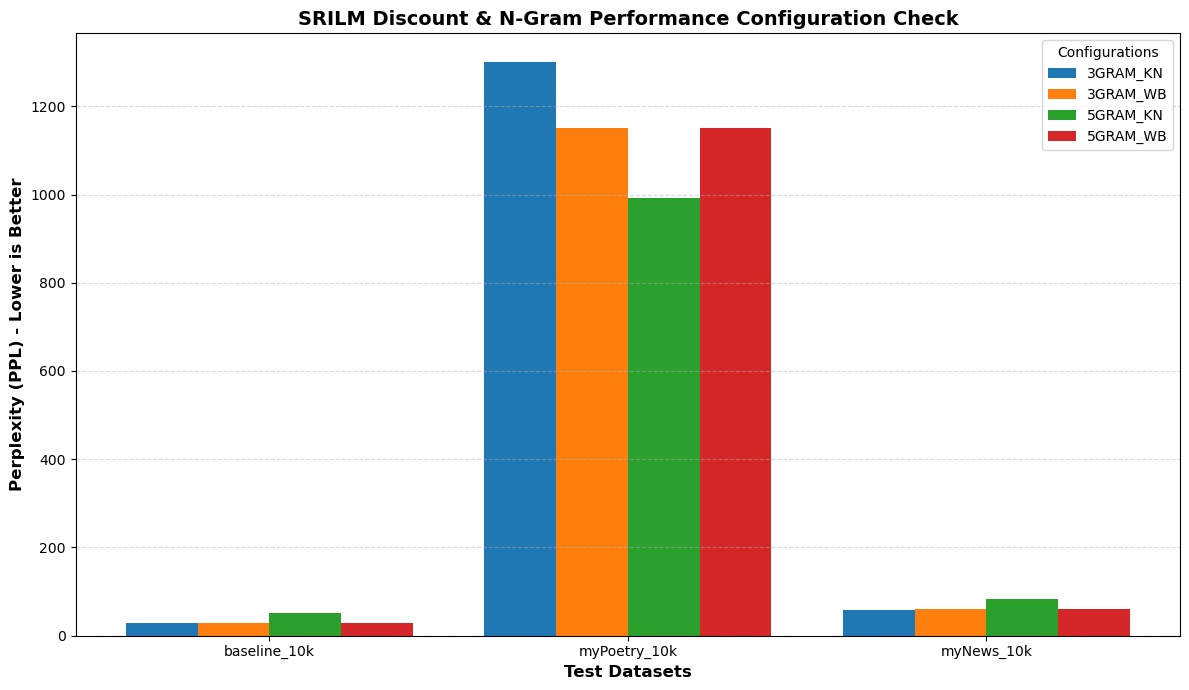

In [17]:
run_srilm_flexible_pipeline("configuration/Srilm_word_config.yaml")

#### Syllable Level SRILM Models

In [18]:
%%writefile configuration/Srilm_syl_config.yaml
# Environment Paths
workspace: "/media/kyalkalay/Data/AI-Class/assignment-5/assignment"
srilm_bin: "/media/kyalkalay/Data/AI-Class/assignment-5/assignment/SRILM/bin/i686-m64"

# File Layouts
files:
  train_file: "dataset/train_clean_my_syl.syl"
  output_dir: "dataset/srilm"

# N-gram configurations to try
models:
  - 3
  - 5

# Discount methods to try (Maps directly to SRILM flags)
discounts:
  - flag: "-kndiscount"
    name: "kn"
  - flag: "-wbdiscount"
    name: "wb"

# Evaluation datasets
test_files:
  baseline_10k: "dataset/test_clean_my_syl_10k.syl"
  myPoetry_10k: "dataset/myPoetry_clean_my_syl_10k.syl"
  myNews_10k: "dataset/myNews_clean_my_syl_10k.syl"

Writing configuration/Srilm_syl_config.yaml


=== Starting Flexible SRILM Loop Execution ===

--- Training SRILM Model: 3GRAM_KN (-kndiscount) ---
Successfully generated ARPA: train_clean_my_srilm_ngram_3_kn.arpa
   Evaluation -> [baseline_10k] -> SRILM PPL: 23.79281
   Evaluation -> [myPoetry_10k] -> SRILM PPL: 1392.661
   Evaluation -> [myNews_10k] -> SRILM PPL: 34.30725

--- Training SRILM Model: 3GRAM_WB (-wbdiscount) ---
Successfully generated ARPA: train_clean_my_srilm_ngram_3_wb.arpa
   Evaluation -> [baseline_10k] -> SRILM PPL: 24.13799
   Evaluation -> [myPoetry_10k] -> SRILM PPL: 972.0511
   Evaluation -> [myNews_10k] -> SRILM PPL: 34.70483

--- Training SRILM Model: 5GRAM_KN (-kndiscount) ---
Successfully generated ARPA: train_clean_my_srilm_ngram_5_kn.arpa
   Evaluation -> [baseline_10k] -> SRILM PPL: 47.36936
   Evaluation -> [myPoetry_10k] -> SRILM PPL: 1023.594
   Evaluation -> [myNews_10k] -> SRILM PPL: 56.13465

--- Training SRILM Model: 5GRAM_WB (-wbdiscount) ---
Successfully generated ARPA: train_clean_my_srilm_

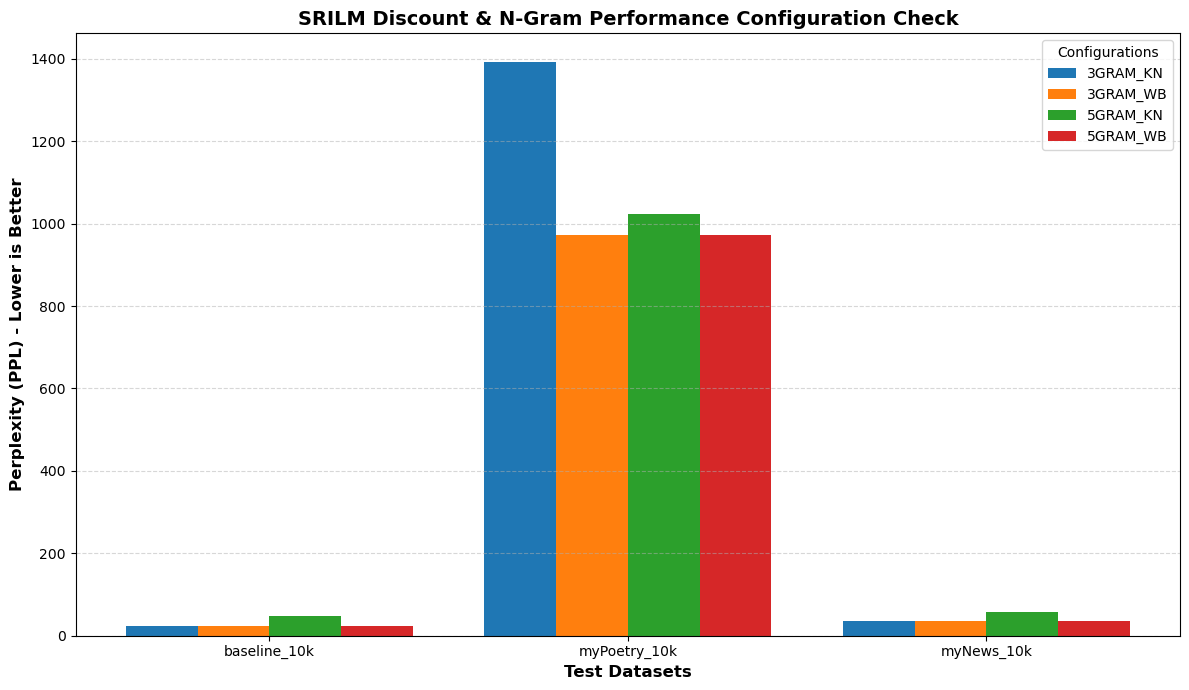

In [19]:
run_srilm_flexible_pipeline("configuration/Srilm_syl_config.yaml")